## Tabular Models — Seattle Airbnb price prediction

Four models in increasing complexity:

| # | Model | Encoding |
|---|---|---|
| 1 | Dummy (mean) | — |
| 2 | Ridge (RidgeCV) | OHE + TargetEnc(neighbourhood) + StandardScaler |
| 3 | Random Forest | OrdinalEncoder |
| 4 | LightGBM | Native categoricals |

Target: `log_price = log(price)` from `data/raw/target.csv` (Person B).  
Features: `data/processed/tabular_train.csv` / `tabular_test.csv` (51 cols, 0 NaN).

## Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

from src.tabular.model import (
    train_dummy, train_ridge, train_rf, train_lgbm, evaluate
)

## Load data and target

In [2]:
X_train = pd.read_csv("../data/processed/tabular_train.csv")
X_test  = pd.read_csv("../data/processed/tabular_test.csv")
target  = pd.read_csv("../data/raw/target.csv")

tgt     = target.set_index("id")["log_price"]
y_train = X_train["id"].map(tgt)
y_test  = X_test["id"].map(tgt)

# Drop any rows missing a target (shouldn't happen with valid split files)
mask_tr = y_train.notna()
mask_te = y_test.notna()
if not mask_tr.all() or not mask_te.all():
    print(f"Dropping {(~mask_tr).sum()} train / {(~mask_te).sum()} test rows (missing target)")
    X_train = X_train[mask_tr].reset_index(drop=True)
    y_train = y_train[mask_tr].reset_index(drop=True)
    X_test  = X_test[mask_te].reset_index(drop=True)
    y_test  = y_test[mask_te].reset_index(drop=True)

print(f"Train : {len(X_train):,} rows")
print(f"Test  : {len(X_test):,} rows")
print(f"Target: log_price in [{y_train.min():.2f}, {y_train.max():.2f}]  "
      f"(median {y_train.median():.2f})")

Train : 4,926 rows
Test  : 1,232 rows
Target: log_price in [2.71, 7.45]  (median 4.99)


## 1. Dummy baseline

In [3]:
dummy = train_dummy(X_train, y_train)

dummy_tr = evaluate(y_train, dummy.predict(X_train), "dummy  train")
dummy_te = evaluate(y_test,  dummy.predict(X_test),  "dummy  test ")

[dummy  train]          RMSE log=0.5791  MAE log=0.4390  R²=0.0000
                        RMSE $=       135  MAE $=        76  MedAE $=        49  MAPE=49.4%
[dummy  test ]          RMSE log=0.5780  MAE log=0.4463  R²=-0.0038
                        RMSE $=       139  MAE $=        80  MedAE $=        50  MAPE=47.3%


## 2. Ridge (RidgeCV)

In [4]:
ridge = train_ridge(X_train, y_train)
print(f"Best alpha (LOO-CV): {ridge['model'].alpha_:.1f}")

ridge_tr = evaluate(y_train, ridge.predict(X_train), "ridge  train")
ridge_te = evaluate(y_test,  ridge.predict(X_test),  "ridge  test ")

Best alpha (LOO-CV): 1.0
[ridge  train]          RMSE log=0.3144  MAE log=0.2355  R²=0.7052
                        RMSE $=        90  MAE $=        45  MedAE $=        25  MAPE=23.8%
[ridge  test ]          RMSE log=0.3462  MAE log=0.2581  R²=0.6398
                        RMSE $=       101  MAE $=        51  MedAE $=        29  MAPE=25.6%


## 3. Random Forest

In [5]:
rf = train_rf(X_train, y_train)

rf_tr = evaluate(y_train, rf.predict(X_train), "rf     train")
rf_te = evaluate(y_test,  rf.predict(X_test),  "rf     test ")

[rf     train]          RMSE log=0.2230  MAE log=0.1596  R²=0.8517
                        RMSE $=        76  MAE $=        32  MedAE $=        16  MAPE=15.8%
[rf     test ]          RMSE log=0.3215  MAE log=0.2328  R²=0.6894
                        RMSE $=       101  MAE $=        48  MedAE $=        24  MAPE=22.6%


## 4. LightGBM

In [6]:
lgbm = train_lgbm(X_train, y_train)

lgbm_tr = evaluate(y_train, lgbm.predict(X_train), "lgbm   train")
lgbm_te = evaluate(y_test,  lgbm.predict(X_test),  "lgbm   test ")

[lgbm   train]          RMSE log=0.0545  MAE log=0.0376  R²=0.9911
                        RMSE $=        24  MAE $=         8  MedAE $=         4  MAPE=3.8%
[lgbm   test ]          RMSE log=0.2910  MAE log=0.2058  R²=0.7455
                        RMSE $=        90  MAE $=        42  MedAE $=        22  MAPE=20.1%


## Results summary

In [7]:
rows = [
    ("Dummy",        dummy_tr,  dummy_te),
    ("Ridge",        ridge_tr,  ridge_te),
    ("RandomForest", rf_tr,     rf_te),
    ("LightGBM",     lgbm_tr,   lgbm_te),
]

summary = pd.DataFrame([
    {
        "model":            name,
        "train RMSE (log)": tr["rmse_log"],
        "test RMSE (log)":  te["rmse_log"],
        "test MAE (log)":   te["mae_log"],
        "test R²":          te["r2"],
        "test RMSE ($)":    te["rmse_dollar"],
        "test MAE ($)":     te["mae_dollar"],
        "test MedAE ($)":   te["median_ae_dollar"],
        "test MAPE (%)":    te["mape"],
    }
    for name, tr, te in rows
]).set_index("model")

summary.style.format({
    "train RMSE (log)": "{:.4f}",
    "test RMSE (log)":  "{:.4f}",
    "test MAE (log)":   "{:.4f}",
    "test R²":          "{:.4f}",
    "test RMSE ($)":    "${:,.0f}",
    "test MAE ($)":     "${:,.0f}",
    "test MedAE ($)":   "${:,.0f}",
    "test MAPE (%)":    "{:.1f}%",
}).highlight_min(axis=0, color="#c6efce")

,train RMSE (log),test RMSE (log),test MAE (log),test R²,test RMSE ($),test MAE ($),test MedAE ($),test MAPE (%)
model,,,,,,,,
Dummy,0.5791,0.5780,0.4463,-0.0038,$139,$80,$50,47.3%
Ridge,0.3144,0.3462,0.2581,0.6398,$101,$51,$29,25.6%
RandomForest,0.2230,0.3215,0.2328,0.6894,$101,$48,$24,22.6%
LightGBM,0.0545,0.2910,0.2058,0.7455,$90,$42,$22,20.1%


## Test RMSE comparison (bar chart)

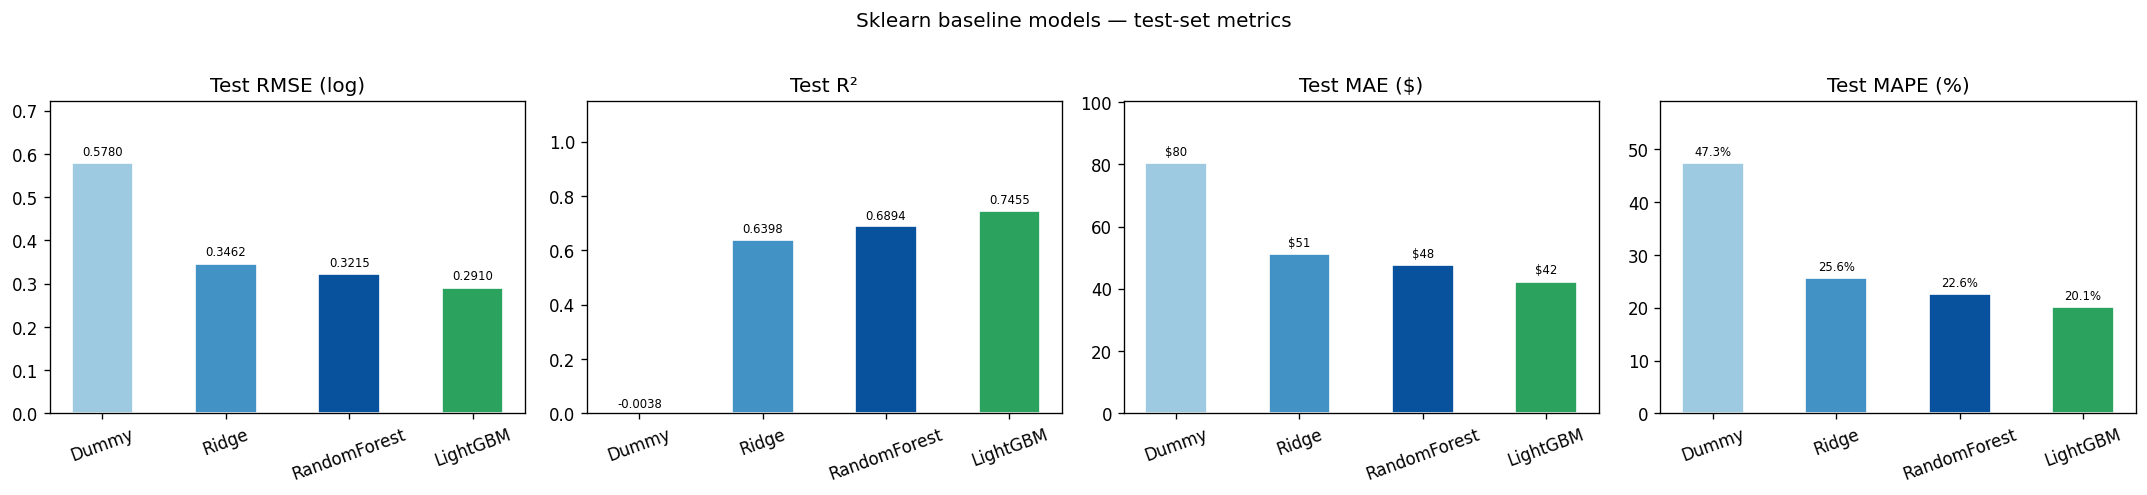

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

models = summary.index.tolist()
colors = ["#9ecae1", "#4292c6", "#08519c", "#2ca25f"]

metrics = [
    ("test RMSE (log)", "Test RMSE (log)",  False),
    ("test R²",         "Test R²",          True),
    ("test MAE ($)",    "Test MAE ($)",      False),
    ("test MAPE (%)",   "Test MAPE (%)",     False),
]

for ax, (col, title, higher_better) in zip(axes, metrics):
    vals = summary[col].values
    bars = ax.bar(models, vals, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        label = f"{val:.4f}" if col in ("test RMSE (log)", "test R²") else \
                f"${val:,.0f}" if "$" in col else f"{val:.1f}%"
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(abs(v) for v in vals) * 0.02,
                label, ha="center", va="bottom", fontsize=7)
    ax.set_title(title)
    ax.set_ylim(0, max(vals) * 1.25) if not higher_better else ax.set_ylim(0, 1.15)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Sklearn baseline models — test-set metrics", y=1.02)
plt.tight_layout()
plt.show()

## Actual vs predicted — all models (test set)

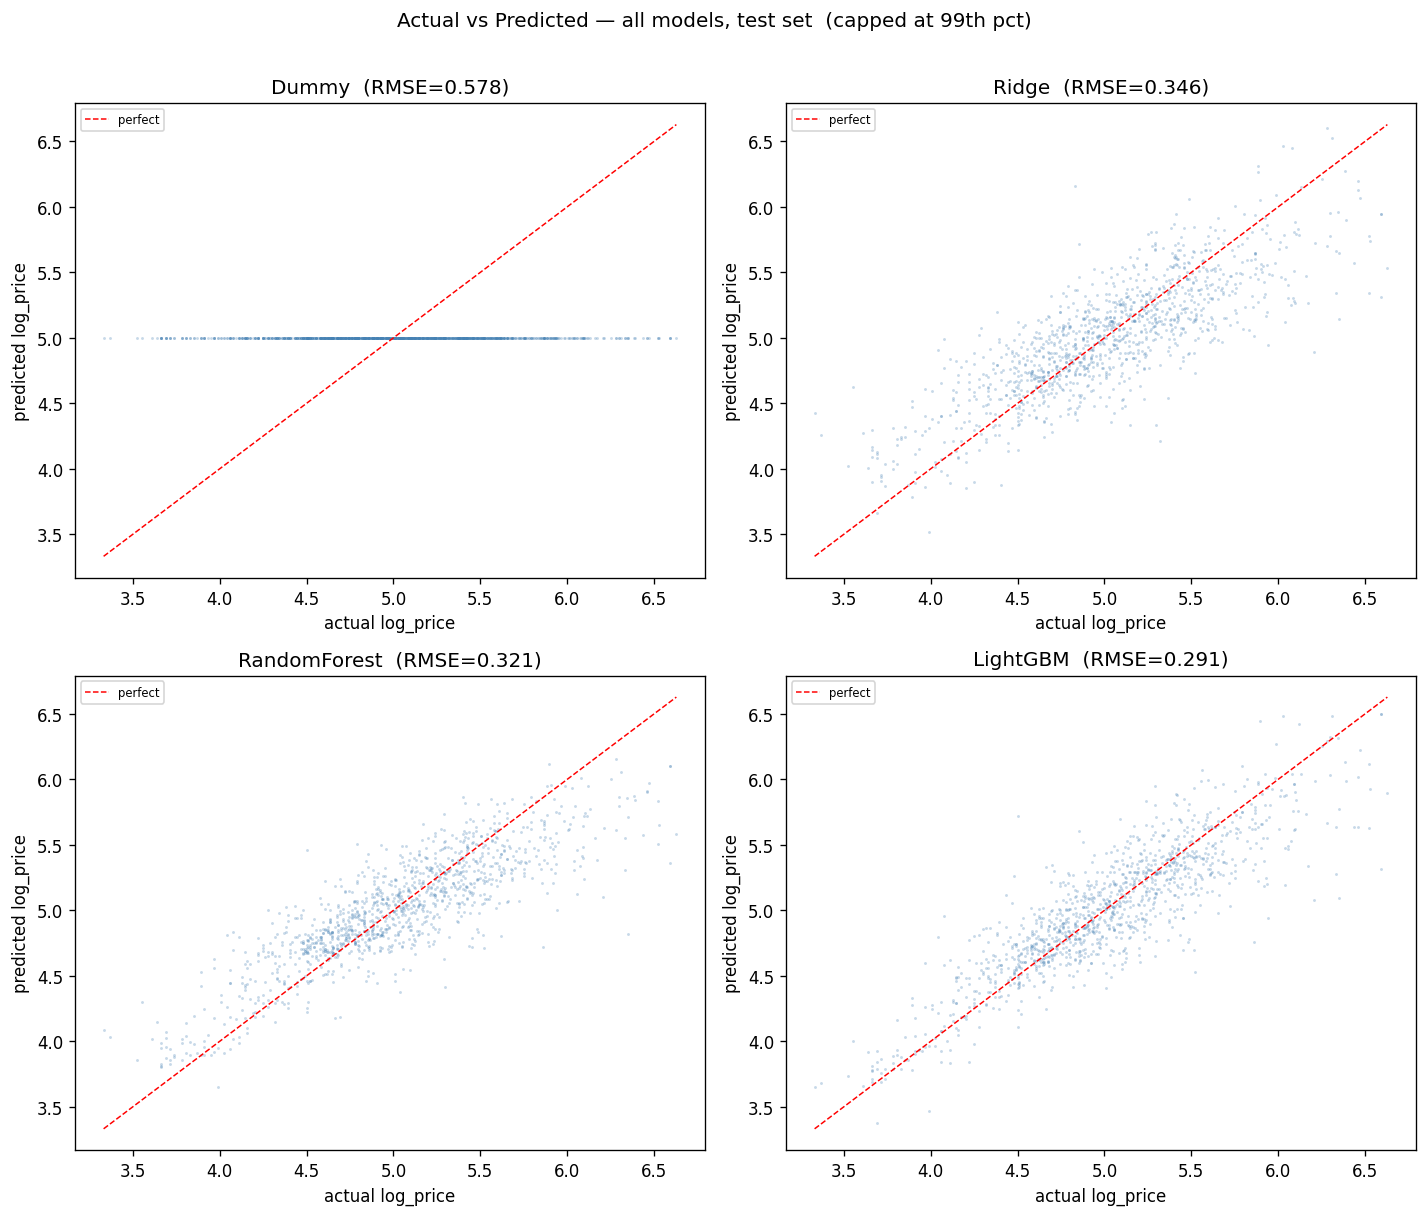

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

model_preds = [
    ("Dummy",        dummy.predict(X_test)),
    ("Ridge",        ridge.predict(X_test)),
    ("RandomForest", rf.predict(X_test)),
    ("LightGBM",     lgbm.predict(X_test)),
]

for ax, (name, preds) in zip(axes.flat, model_preds):
    cap = np.percentile(y_test.values, 99)
    mask = y_test.values <= cap
    ax.scatter(y_test.values[mask], preds[mask], s=3, alpha=0.3, linewidths=0, color="steelblue")
    lims = [y_test.values[mask].min(), cap]
    ax.plot(lims, lims, "r--", linewidth=0.9, label="perfect")
    rmse = np.sqrt(np.mean((y_test.values - preds) ** 2))
    ax.set_title(f"{name}  (RMSE={rmse:.3f})")
    ax.set_xlabel("actual log_price")
    ax.set_ylabel("predicted log_price")
    ax.legend(fontsize=7)

plt.suptitle("Actual vs Predicted — all models, test set  (capped at 99th pct)", y=1.01)
plt.tight_layout()
plt.show()

## Dollar-space error distribution — LightGBM (test set)

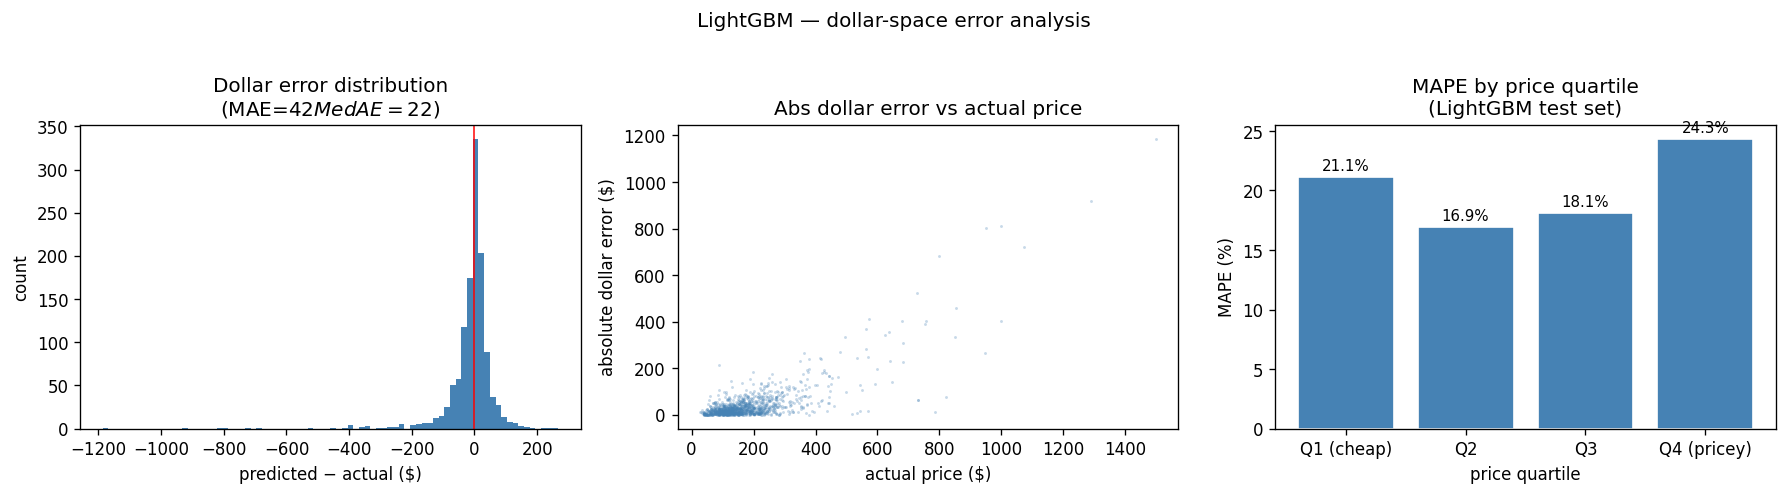

In [10]:
lgbm_preds_log = lgbm.predict(X_test)
price_actual   = np.exp(y_test.values)
price_pred     = np.exp(lgbm_preds_log)
dollar_errors  = price_pred - price_actual

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of dollar errors
axes[0].hist(dollar_errors, bins=80, color="steelblue", edgecolor="none")
axes[0].axvline(0, color="red", linewidth=0.9)
axes[0].set_xlabel("predicted − actual ($)")
axes[0].set_ylabel("count")
axes[0].set_title(f"Dollar error distribution\n(MAE=${np.mean(np.abs(dollar_errors)):,.0f}  "
                  f"MedAE=${np.median(np.abs(dollar_errors)):,.0f})")

# Absolute dollar error vs actual price
axes[1].scatter(price_actual, np.abs(dollar_errors), s=3, alpha=0.3, linewidths=0, color="steelblue")
axes[1].set_xlabel("actual price ($)")
axes[1].set_ylabel("absolute dollar error ($)")
axes[1].set_title("Abs dollar error vs actual price")

# MAPE by price tier
tiers   = pd.qcut(price_actual, q=4, labels=["Q1 (cheap)", "Q2", "Q3", "Q4 (pricey)"])
tier_mape = {}
for t in tiers.unique():
    mask_t = tiers == t
    tier_mape[str(t)] = float(np.mean(np.abs((price_actual[mask_t] - price_pred[mask_t]) / price_actual[mask_t])) * 100)

tier_mape = dict(sorted(tier_mape.items()))
axes[2].bar(tier_mape.keys(), tier_mape.values(), color="steelblue", edgecolor="white")
for x, (k, v) in enumerate(tier_mape.items()):
    axes[2].text(x, v + 0.3, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
axes[2].set_xlabel("price quartile")
axes[2].set_ylabel("MAPE (%)")
axes[2].set_title("MAPE by price quartile\n(LightGBM test set)")

plt.suptitle("LightGBM — dollar-space error analysis", y=1.02)
plt.tight_layout()
plt.show()

## Feature importances

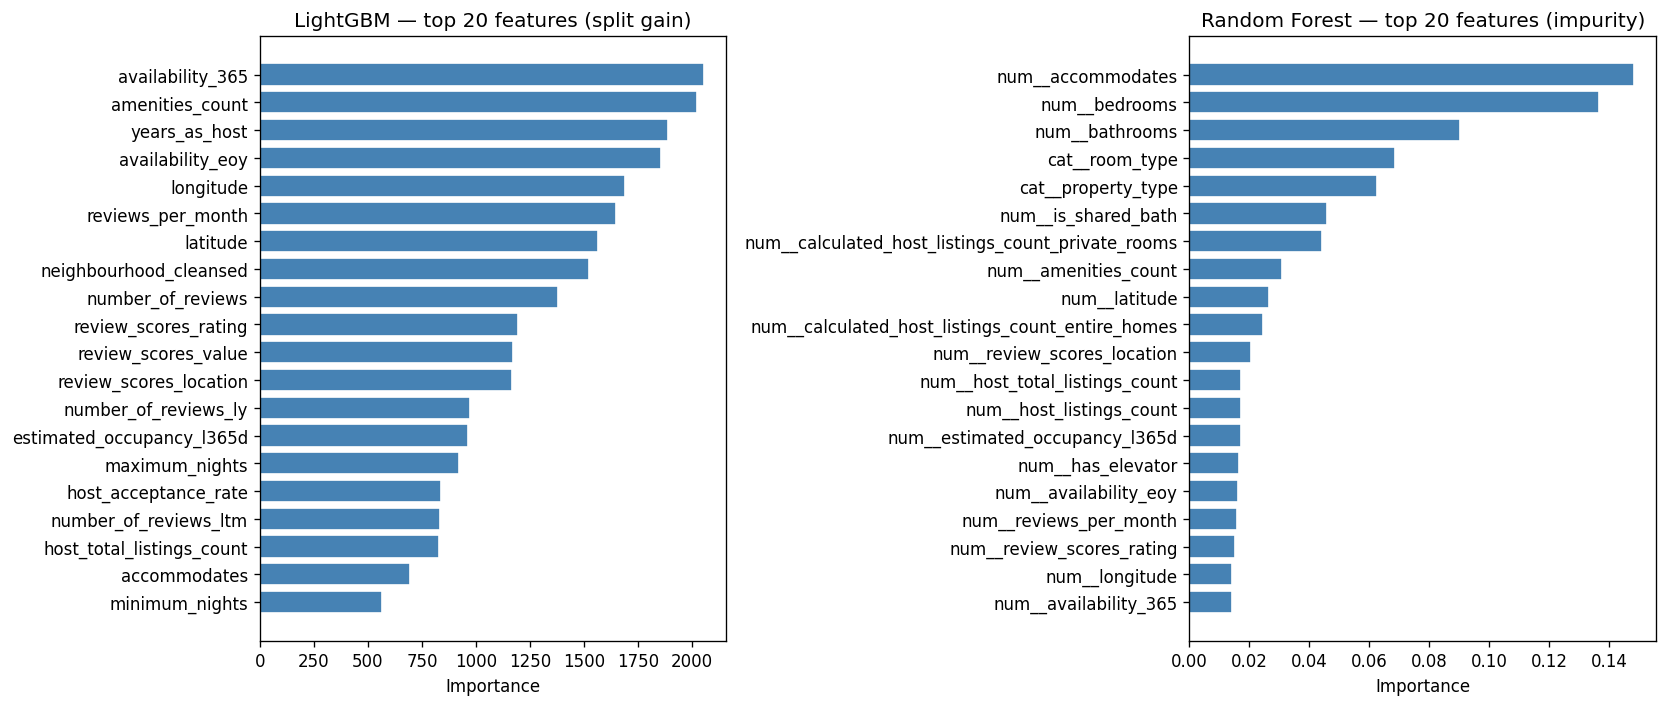

In [11]:
# ── LightGBM importances ───────────────────────────────────────────────────────
lgbm_imp = (
    pd.Series(lgbm.feature_importances_, index=lgbm.feature_name_)
    .sort_values(ascending=False)
    .head(20)
)

# ── Random Forest importances ─────────────────────────────────────────────────
rf_feature_names = rf["ct"].get_feature_names_out().tolist()
rf_imp = (
    pd.Series(rf["model"].feature_importances_, index=rf_feature_names)
    .sort_values(ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, imp, title in zip(
    axes,
    [lgbm_imp, rf_imp],
    ["LightGBM — top 20 features (split gain)",
     "Random Forest — top 20 features (impurity)"],
):
    ax.barh(imp.index[::-1], imp.values[::-1], color="steelblue", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## Residual analysis — LightGBM (test set)

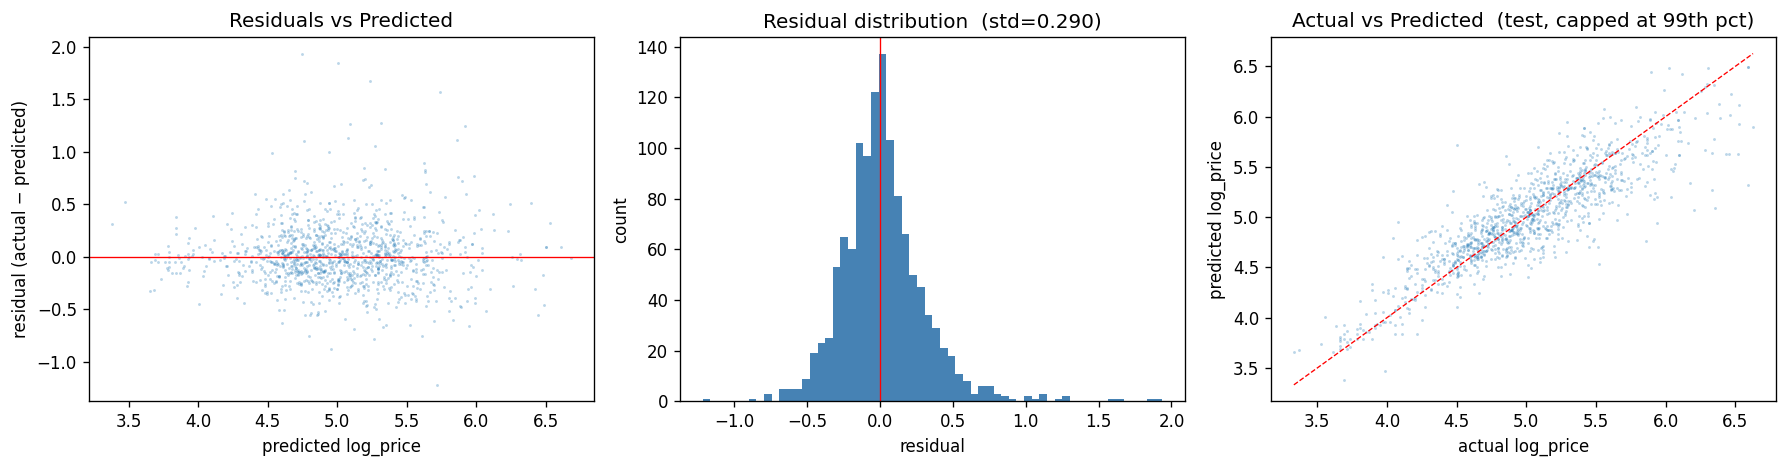

In [12]:
y_pred_te = lgbm.predict(X_test)
residuals  = y_test.values - y_pred_te

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs predicted
axes[0].scatter(y_pred_te, residuals, s=3, alpha=0.3, linewidths=0)
axes[0].axhline(0, color="red", linewidth=0.8)
axes[0].set_xlabel("predicted log_price")
axes[0].set_ylabel("residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")

# Residual distribution
axes[1].hist(residuals, bins=60, edgecolor="none", color="steelblue")
axes[1].axvline(0, color="red", linewidth=0.8)
axes[1].set_xlabel("residual")
axes[1].set_ylabel("count")
axes[1].set_title(f"Residual distribution  (std={residuals.std():.3f})")

# Actual vs predicted (capped at 99th pct for visual clarity)
cap = np.percentile(y_test.values, 99)
mask = y_test.values <= cap
axes[2].scatter(y_test.values[mask], y_pred_te[mask], s=3, alpha=0.3, linewidths=0)
lims = [y_test.values[mask].min(), cap]
axes[2].plot(lims, lims, "r--", linewidth=0.8)
axes[2].set_xlabel("actual log_price")
axes[2].set_ylabel("predicted log_price")
axes[2].set_title("Actual vs Predicted  (test, capped at 99th pct)")

plt.tight_layout()
plt.show()

## Residuals by room type

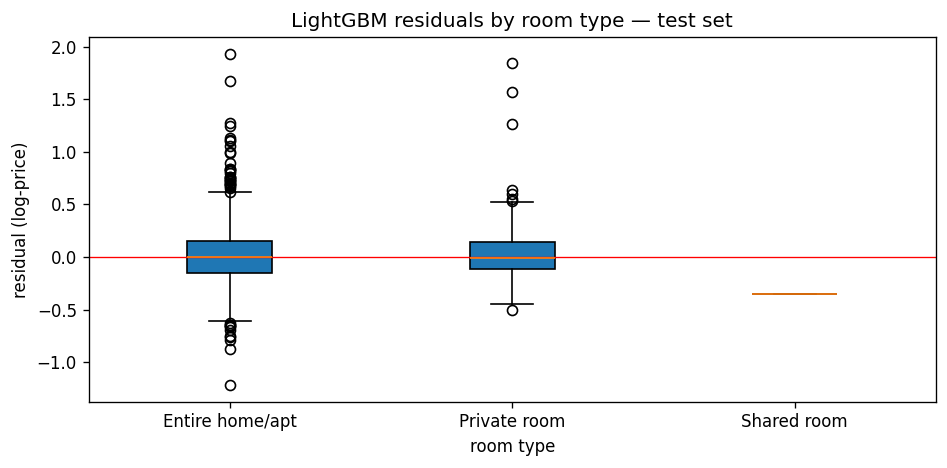

Median residual by room type:
  Entire home/apt       n=1047  median=+0.001  std=0.290
  Private room          n= 184  median=-0.004  std=0.290
  Shared room           n=   1  median=-0.355  std=0.000


In [13]:
room_types = X_test["room_type"].values
unique_rooms = sorted(set(room_types))
data_by_room = [residuals[room_types == rt] for rt in unique_rooms]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(data_by_room, tick_labels=unique_rooms, patch_artist=True)
ax.axhline(0, color="red", linewidth=0.8)
ax.set_xlabel("room type")
ax.set_ylabel("residual (log-price)")
ax.set_title("LightGBM residuals by room type — test set")
plt.tight_layout()
plt.show()

print("Median residual by room type:")
for rt, d in zip(unique_rooms, data_by_room):
    print(f"  {rt:<20}  n={len(d):>4}  median={np.median(d):+.3f}  std={d.std():.3f}")

## Ridge coefficients (top 20 by absolute value)

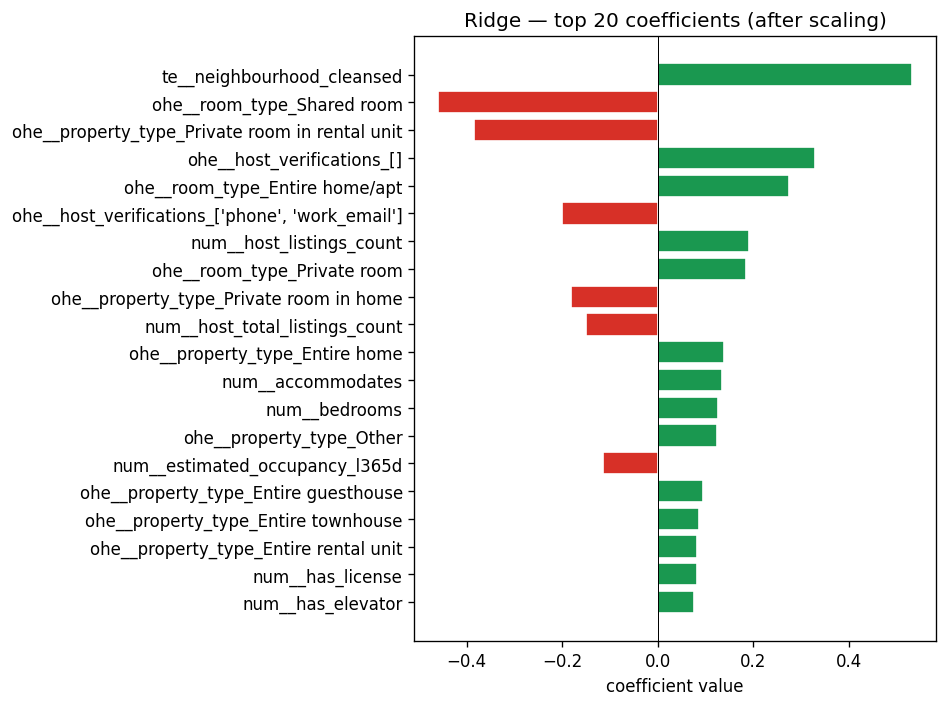

In [14]:
ridge_names = ridge["ct"].get_feature_names_out().tolist()
ridge_coefs = pd.Series(
    ridge["model"].coef_, index=ridge_names
).reindex(pd.Series(ridge["model"].coef_, index=ridge_names).abs().sort_values(ascending=False).index)

top = ridge_coefs.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
colors_coef = ["#d73027" if v < 0 else "#1a9850" for v in top.values[::-1]]
ax.barh(top.index[::-1], top.values[::-1], color=colors_coef, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.6)
ax.set_title("Ridge — top 20 coefficients (after scaling)")
ax.set_xlabel("coefficient value")
plt.tight_layout()
plt.show()

## MAPE by price quartile — all models

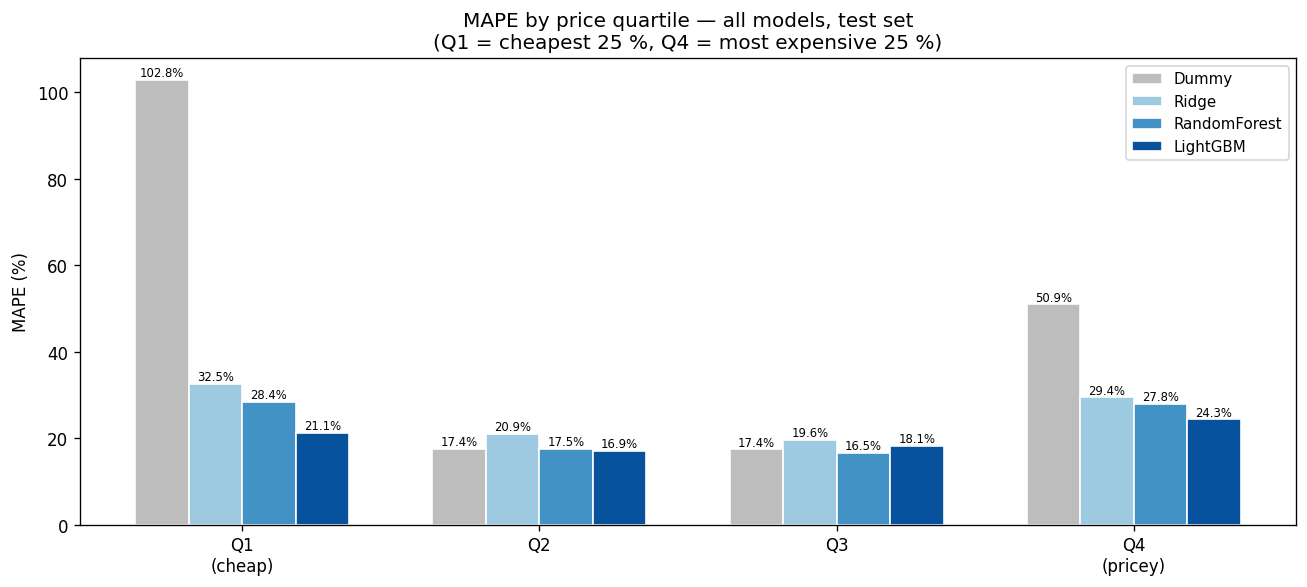

In [15]:
all_preds = {
    "Dummy":        dummy.predict(X_test),
    "Ridge":        ridge.predict(X_test),
    "RandomForest": rf.predict(X_test),
    "LightGBM":     lgbm.predict(X_test),
}

price_actual = np.exp(y_test.values)
tiers        = pd.qcut(price_actual, q=4, labels=["Q1\n(cheap)", "Q2", "Q3", "Q4\n(pricey)"])
tier_names   = ["Q1\n(cheap)", "Q2", "Q3", "Q4\n(pricey)"]
x_pos        = np.arange(len(tier_names))
width        = 0.18
model_colors = ["#bdbdbd", "#9ecae1", "#4292c6", "#08519c"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, preds) in enumerate(all_preds.items()):
    price_pred_m = np.exp(preds)
    mapes = [
        float(np.mean(np.abs((price_actual[tiers == t] - price_pred_m[tiers == t]) / price_actual[tiers == t])) * 100)
        for t in tier_names
    ]
    bars = ax.bar(x_pos + i * width, mapes, width, label=name, color=model_colors[i], edgecolor="white")
    for bar, v in zip(bars, mapes):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x_pos + 1.5 * width)
ax.set_xticklabels(tier_names)
ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE by price quartile — all models, test set\n"
             "(Q1 = cheapest 25 %, Q4 = most expensive 25 %)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Save LightGBM predictions

In [16]:
from pathlib import Path
out = Path("../data/processed")

lgbm_test_log  = lgbm.predict(X_test)
lgbm_train_log = lgbm.predict(X_train)

pd.DataFrame({
    "id":               X_test["id"].values,
    "log_price_actual": y_test.values,
    "log_price_pred":   lgbm_test_log,
    "price_actual":     np.exp(y_test.values),
    "price_pred":       np.exp(lgbm_test_log),
}).to_csv(out / "tabular_preds_test.csv", index=False)

pd.DataFrame({
    "id":               X_train["id"].values,
    "log_price_actual": y_train.values,
    "log_price_pred":   lgbm_train_log,
    "price_actual":     np.exp(y_train.values),
    "price_pred":       np.exp(lgbm_train_log),
}).to_csv(out / "tabular_preds_train.csv", index=False)

print(f"Saved tabular_preds_test.csv   ({len(X_test):,} rows)  [id, log_price_actual, log_price_pred, price_actual, price_pred]")
print(f"Saved tabular_preds_train.csv  ({len(X_train):,} rows)  [id, log_price_actual, log_price_pred, price_actual, price_pred]")

Saved tabular_preds_test.csv   (1,232 rows)  [id, log_price_actual, log_price_pred, price_actual, price_pred]
Saved tabular_preds_train.csv  (4,926 rows)  [id, log_price_actual, log_price_pred, price_actual, price_pred]
